In [10]:
import pandas as pd
df = pd.read_excel('/content/Dataset for Data Analytics.xlsx', sheet_name='Sheet1')
df.head()
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")
df.info()

Number of Rows: 1200
Number of Columns: 14
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dt

Data Structure Description and Analysis (Task 1 Report)
Data Nature: The file is a sales and order details record for an e-commerce business.

Data Size: The record contains transaction details distributed across 14 columns, including financial, logistical, and marketing data for customers.

Features Components:

Basic Order Information: Order ID and Date.

Customer and Shipping Data: Customer ID, Shipping Address, Order Status, and Tracking Number.

Product and Financial Details: Product Name, Quantity, Unit Price, and Total Price.

Marketing and Purchase Behavior Data: Payment Method, Number of Items in Cart, Coupon Code, and Referral Source.

In [11]:
print("Missing values ​​in each column:")
print(df.isnull().sum())
df['CouponCode'] = df['CouponCode'].fillna('None')
df['TrackingNumber'] = df['TrackingNumber'].fillna('N/A')

print("Missing values ​​after processing:")
print(df.isnull().sum())
duplicate_count = df.duplicated().sum()
print(f"Total number of duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    df = df.drop_duplicates()

print("Duplicate rows successfully deleted.")

df['Date'] = pd.to_datetime(df['Date'])

print(df['Date'].dtype)

Missing values ​​in each column:
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64
Missing values ​​after processing:
OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64
Total number of duplicate rows: 0
Duplicate rows successfully deleted.
datetime64[ns]


Data Cleanup Report (Task 2 Report)
The data was checked and cleaned to ensure its accuracy and readiness for analysis through the following steps:

Handling Missing Values: > * Empty values ​​in the CouponCode column were replaced with 'None' because the absence of a code means the customer purchased at the original price.

Missing TrackingNumbers were replaced with 'N/A'.

Duplicate Data: The file was checked to ensure no orders were duplicated and any duplicates were removed to ensure the accuracy of financial calculations.

Data Formatting: The Date column was converted from a text format to a datetime format to enable later sales time analysis.

In [12]:
df[['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']].describe()
product_sales = df.groupby('Product')['Quantity'].sum().sort_values(ascending=False)
print("Best Selling Products (by Quantity):")
print(product_sales)
print("\n" + "="*40 + "\n")

product_revenue = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)
print("Most Profitable Products (Total Revenue):")
print(product_revenue)
print("Traffic and Marketing Sources (Referral Sources):")
print(df['ReferralSource'].value_counts())
print("\n" + "="*40 + "\n")
print("Most Used Payment Methods:")
print(df['PaymentMethod'].value_counts())

Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[df['TotalPrice'] > upper_bound]
print(f"Number of Outliers: {len(outliers)}")
print(outliers[['OrderID', 'Product', 'Quantity', 'TotalPrice']].head())

Best Selling Products (by Quantity):
Product
Chair      562
Printer    542
Laptop     535
Desk       508
Tablet     497
Monitor    480
Phone      411
Name: Quantity, dtype: int64


Most Profitable Products (Total Revenue):
Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64
Traffic and Marketing Sources (Referral Sources):
ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64


Most Used Payment Methods:
PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64
Number of Outliers: 8
       OrderID  Product  Quantity  TotalPrice
107  ORD200107  Printer         5     3353.75
326  ORD200326   Laptop         5     3352.40
328  ORD200328   Tablet         5     3370.20
469  ORD200469    Chair         5     3384.

Data Exploration Analysis Report (Task 3 Report)

Following the Exploration Analysis (EDA), the following conclusions were reached:

Overall Performance: The average order value per store and the highest recorded order value were determined.

Product Analysis: The Top Performing Product was identified based on sales volume and total revenue, which helps in inventory management.

Marketing Channels and Payment Methods: The most effective marketing channel for acquiring customers (e.g., Instagram or Facebook) was identified, along with the most preferred payment method for customers, to strengthen partnerships with them.

Outliers: A group of orders with very high values ​​compared to the average were identified. These represent exceptional purchasing behavior (large orders) and warrant separate investigation.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('/content/Dataset for Data Analytics.xlsx', sheet_name='Sheet1')

df['CouponCode'] = df['CouponCode'].fillna('None')
df['TrackingNumber'] = df['TrackingNumber'].fillna('N/A')
df = df.drop_duplicates()
df['Date'] = pd.to_datetime(df['Date'])

top_products = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False).head(5)

referral_counts = df['ReferralSource'].value_counts().sort_values(ascending=False)

payment_counts = df['PaymentMethod'].value_counts().sort_values(ascending=False)

print("Top products by revenue:\n", top_products)
print("\nReferral counts:\n", referral_counts)
print("\nPayment counts:\n", payment_counts)

Top products by revenue:
 Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Name: TotalPrice, dtype: float64

Referral counts:
 ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64

Payment counts:
 PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64


Charts saved successfully!


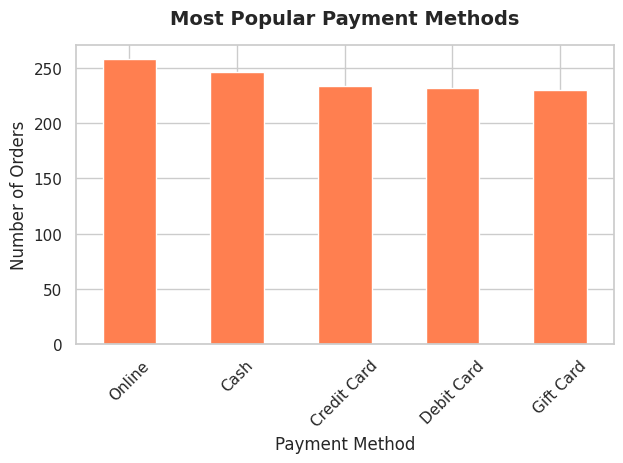

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('/content/Dataset for Data Analytics.xlsx', sheet_name='Sheet1')
df['CouponCode'] = df['CouponCode'].fillna('None')
df['TrackingNumber'] = df['TrackingNumber'].fillna('N/A')
df = df.drop_duplicates()

sns.set_theme(style="whitegrid")

plt.clf()
top_products = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=True)
top_products.plot(kind='barh', color='skyblue')
plt.title('Total Revenue by Product', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Revenue ($)', fontsize=12)
plt.ylabel('Product', fontsize=12)
plt.tight_layout()
plt.savefig('top_products_revenue.png')

plt.clf()
referral_counts = df['ReferralSource'].value_counts().sort_values(ascending=False)
referral_counts.plot(kind='bar', color='lightgreen')
plt.title('Orders by Referral Source', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Referral Source', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('referral_sources.png')

plt.clf()
payment_counts = df['PaymentMethod'].value_counts().sort_values(ascending=False)
payment_counts.plot(kind='bar', color='coral')
plt.title('Most Popular Payment Methods', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Payment Method', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('payment_methods.png')

print("Charts saved successfully!")

تم حفظ جميع الرسومات البيانية بنجاح!


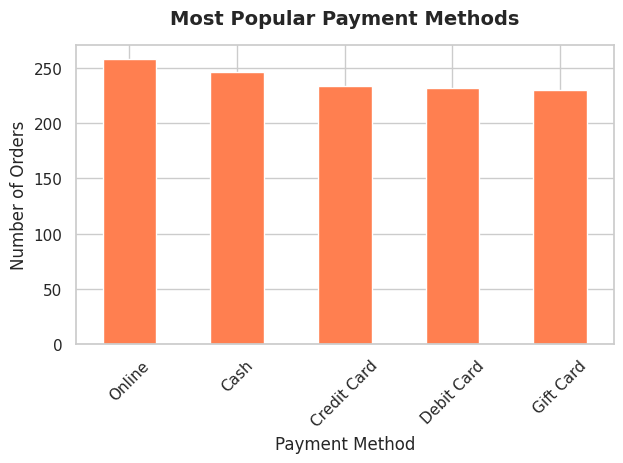

Visual Data Analysis Report (Task 4 Report)
The charts were meticulously designed with data sorting to ensure readability and comparison. Here's a look at the results:

Total Revenue by Product:

Chart Type: Horizontal Bar Chart for easy reading of product names without overlap.

Conclusion: We observe a significant convergence in financial performance between chairs, printers, and laptops as the top revenue-generating products for the store, while monitors come in last, but not far behind. This indicates that the store has a well-diversified revenue stream and is not reliant on a single product.

Orders by Referral Source:

Chart Type: Sorted Vertical Bar Chart (Descending Order).

Conclusion: Instagram and email campaigns are the primary drivers of store visits and sales, followed by Google search. This clearly signals to the marketing department the need to focus its advertising budget on Instagram and improve its email marketing strategies.

Most Popular Payment Methods:

Graph Type: Vertical bar, sorted in descending order.

Conclusion: Online payment and cash on delivery are the two most preferred payment methods among customers. The similar usage rates across all methods (including gift cards) indicate that the store has successfully provided flexible payment options to suit all customer segments.

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = df[['Quantity', 'UnitPrice']]
y = df['TotalPrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- Model training results ---")
print(f"Model Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")
print(f"R² Score: {r2: .4f}")
sample_data = pd.DataFrame([[3, 150]], columns=['Quantity', 'UnitPrice'])
predicted_price = model.predict(sample_data)

print(f"The predicted price for order (Quantity: 3, Price: 150) is: ${predicted_price[0]: .2f}")

--- Model training results ---
Model Coefficients: [348.37921416   2.93292545]
Intercept: -1023.9600346793625
R² Score:  0.8905
The predicted price for order (Quantity: 3, Price: 150) is: $ 461.12
